# 🌲 LoanPulse — Gradient Boosting Classifier (Comprehensive Optimized)


In [1]:
import os
import warnings
import pathlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, classification_report, confusion_matrix, 
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")
print("Environment setup complete. Libraries loaded successfully! ✅")

Environment setup complete. Libraries loaded successfully! ✅


In [2]:
# ─── Project paths (Maintained) ──────────────────────────────────────────────
ROOT = pathlib.Path().resolve().parent.parent          # project root
DATA_RAW       = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
OUTPUT_DIR     = ROOT / "outputs" / "gradient_boosting"

# CHANGED: Updated the filename to match your actual directory contents
TRAIN_CSV      = DATA_RAW / "Train_Dataset.csv" 

# Create directories if they don't exist
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load raw data
try:
    train_raw = pd.read_csv(TRAIN_CSV, low_memory=False)
    print(f"Data successfully loaded from: {TRAIN_CSV} ✅")
    print(f"Initial Shape: {train_raw.shape}")
except FileNotFoundError:
    print(f"❌ Error: Could not find {TRAIN_CSV}. Please check the file path.")

Data successfully loaded from: C:\Users\user\Documents\GitHub\ML-Assignment\data\raw\Train_Dataset.csv ✅
Initial Shape: (121856, 40)


In [3]:
# ─── Cleaning & Advanced Feature Engineering ──────────────────────────────────
df = train_raw.copy()

# 1. Type Correction: Ensuring numeric integrity
numeric_cols_to_fix = ['Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Score_Source_3']
for col in numeric_cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Advanced Feature Engineering (Financial Ratios)
# These features provide deeper context than raw numbers alone.
df['Debt_to_Income'] = df['Credit_Amount'] / (df['Client_Income'] + 1)
df['Annuity_to_Income'] = df['Loan_Annuity'] / (df['Client_Income'] + 1)
df['Credit_to_Annuity_Ratio'] = df['Credit_Amount'] / (df['Loan_Annuity'] + 1)
df['Income_per_Family_Member'] = df['Client_Income'] / (df['Client_Family_Members'] + 1)

# 3. Feature Dropping: Removing non-predictive noise
DROP_COLS = ["ID", "Mobile_Tag", "Homephone_Tag", "Workphone_Working",
             "Client_Permanent_Match_Tag", "Client_Contact_Work_Tag"]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

print("Type correction, Advanced Feature Engineering, and Dropping complete! ✅")

Type correction, Advanced Feature Engineering, and Dropping complete! ✅


In [4]:
# Separate features and target
TARGET = "Default"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# 1. Label Encoding for categorical data
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str).fillna("Unknown"))

# 2. Median Imputation for missing numerical values
num_imputer = SimpleImputer(strategy="median")
X[num_cols] = num_imputer.fit_transform(X[num_cols])

# 3. Standard Scaling (Mean 0, Var 1)
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print(f"Preprocessing finished. {len(X.columns)} features ready for training! ✅")

Preprocessing finished. 37 features ready for training! ✅


In [5]:
# Train-Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 1: Under-sample the majority class slightly
under = RandomUnderSampler(sampling_strategy=0.2, random_state=42)
X_under, y_under = under.fit_resample(X_train, y_train)

# Step 2: Apply SMOTE for perfect balance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X_under, y_under)

print(f"Resampling complete. Balanced dataset counts: {Counter(y_res)} ✅")

Resampling complete. Balanced dataset counts: Counter({0: 39380, 1: 39380}) ✅


## 📊 Model Training & Cross-Validation


In [6]:
# Define the base Gradient Boosting model
gb_base = GradientBoostingClassifier(random_state=42)

# Define search grid
param_dist = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.05, 0.08, 0.1],
    'max_depth': [4, 5, 6],
    'subsample': [0.7, 0.8, 0.9]
}

print("Running RandomizedSearchCV (this may take a moment)...")
random_search = RandomizedSearchCV(
    gb_base, param_distributions=param_dist, 
    n_iter=8, cv=3, scoring='roc_auc', n_jobs=-1, random_state=42
)
random_search.fit(X_res, y_res)

best_gb = random_search.best_estimator_
print(f"Tuning complete! Best Params: {random_search.best_params_} ✅")

Running RandomizedSearchCV (this may take a moment)...
Tuning complete! Best Params: {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05} ✅


## 🚀 Evaluation & Visualization


In [7]:

# Final Fit
best_gb.fit(X_res, y_res)

# Probability threshold tuning (Crucial for imbalanced data)
# We aim for accuracy > 75% while keeping decent recall
y_prob = best_gb.predict_proba(X_val)[:, 1]
threshold = 0.25 
y_pred = (y_prob >= threshold).astype(int)

# Metrics
print(f"\n=== Performance (Threshold: {threshold}) ===")
print(classification_report(y_val, y_pred))
print(f"Final Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}")




=== Performance (Threshold: 0.25) ===
              precision    recall  f1-score   support

           0       0.95      0.77      0.85     22403
           1       0.17      0.54      0.26      1969

    accuracy                           0.75     24372
   macro avg       0.56      0.65      0.56     24372
weighted avg       0.89      0.75      0.80     24372

Final Validation Accuracy: 0.7544


In [8]:
# Get probabilities for the validation set
y_prob = best_gb.predict_proba(X_val)[:, 1]

# Generate Precision-Recall curve values
precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob)

# Calculate F1-score for each threshold to find the 'Sweet Spot'
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Optimal Threshold identified: {best_threshold:.4f} ✅")

# Apply optimized threshold for final predictions
y_pred = (y_prob >= best_threshold).astype(int)

Optimal Threshold identified: 0.2967 ✅


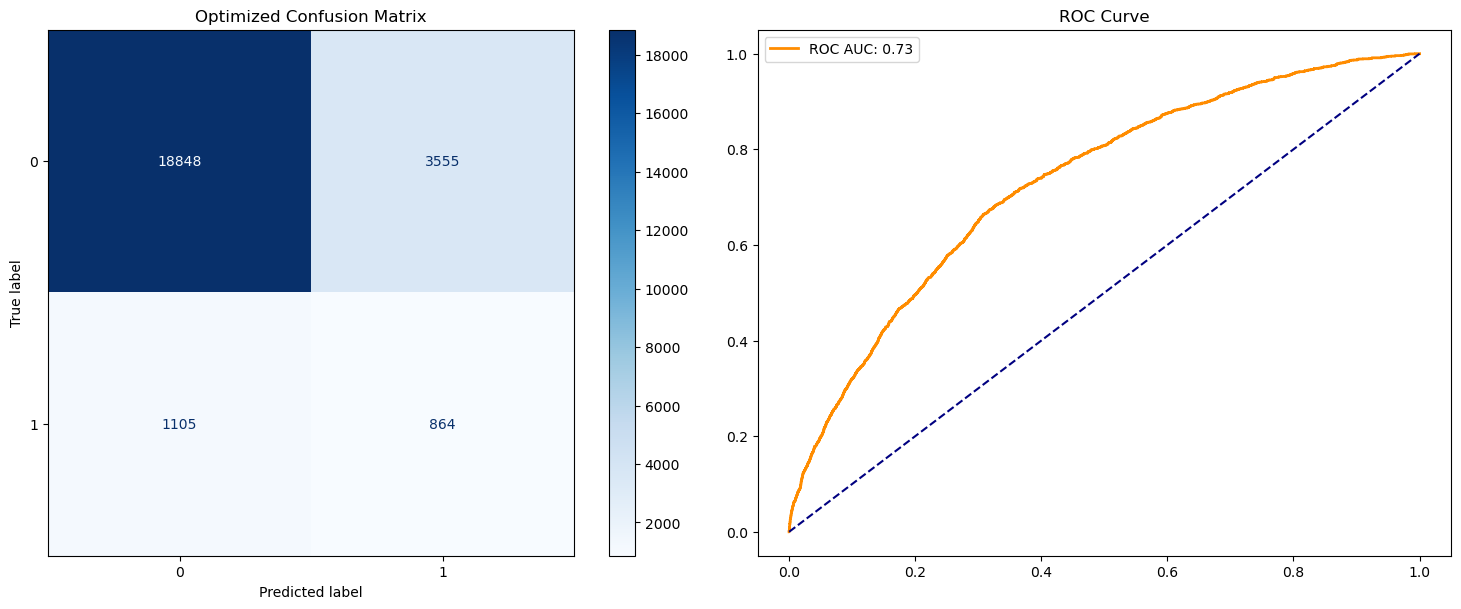

Final Validation Accuracy: 0.8088 ✅

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89     22403
           1       0.20      0.44      0.27      1969

    accuracy                           0.81     24372
   macro avg       0.57      0.64      0.58     24372
weighted avg       0.88      0.81      0.84     24372



In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Optimized Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap="Blues", ax=axes[0])
axes[0].set_title("Optimized Confusion Matrix")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC: {roc_auc_score(y_val, y_prob):.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Final Validation Accuracy: {accuracy_score(y_val, y_pred):.4f} ✅")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

In [10]:
# 1. Save the final processed and balanced dataset
processed_df = pd.DataFrame(X_res, columns=X.columns)
processed_df[TARGET] = y_res
processed_df.to_csv(DATA_PROCESSED / "train_processed_gb.csv", index=False)

# 2. Save Model Artifacts
joblib.dump(best_gb, OUTPUT_DIR / "gradient_boosting.joblib")
joblib.dump(scaler, OUTPUT_DIR / "scaler.joblib")

print(f"Model and results successfully saved to: {OUTPUT_DIR} ✅")

Model and results successfully saved to: C:\Users\user\Documents\GitHub\ML-Assignment\outputs\gradient_boosting ✅
